
# Practical 4: Transfer Learning (Pretrained Embeddings, Fine‑Tuning, Differential LR)


In [ ]:

# Import required libraries (same as Practical 3)
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print(tf.__version__)


2.19.0


In [ ]:

# Define image size and class names (same as Practical 3)
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]
NUM_CLASSES = 5


## Dataset & Loader

In [ ]:

# Load dataset from CSV and parse image-label pairs (identical pattern to P3)
def read_and_decode(filename, resize_dims):
    img_bytes = tf.io.read_file(filename)
    img = tf.image.decode_jpeg(img_bytes, channels=IMG_CHANNELS)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, resize_dims)
    return img

def parse_csvline(csv_line):
    record_default = ["", ""]
    filename, label_string = tf.io.decode_csv(csv_line, record_default)
    img = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])
    label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))
    return img, label


In [ ]:

# You can change the batch size here to 16, 32, 64, etc.
# Load training and evaluation datasets from Google Cloud (same source as P3)
train_dataset = (
    tf.data.TextLineDataset("gs://cloud-ml-data/img/flower_photos/train_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

eval_dataset = (
    tf.data.TextLineDataset("gs://cloud-ml-data/img/flower_photos/eval_set.csv")
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)


## Helper: Plot Training vs Validation

In [ ]:

def plot_history(h, title):
    plt.figure()
    plt.plot(h.history.get("loss", []), label="train_loss")
    plt.plot(h.history.get("val_loss", []), label="val_loss")
    plt.title(title + " — Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

    plt.figure()
    plt.plot(h.history.get("accuracy", []), label="train_acc")
    plt.plot(h.history.get("val_accuracy", []), label="val_acc")
    plt.title(title + " — Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.show()



## What is Transfer Learning?
- A big CNN (trained on **ImageNet**) already learned **edges, textures, shapes**.
- We **reuse** it as a **feature extractor**, then add a small classifier for our 5 classes.
- Later, we can **unfreeze some top layers** and **train slowly** (small learning rate) to adapt to our flowers.


# Feature Extraction vs. Fine‑Tuning

**Feature Extraction** (a gentle start):
- We **freeze** the pre‑trained backbone (e.g., MobileNetV2, ResNet50) so its weights do **not** change.
- We **add a small classifier head** (Dense layers) on top and only train that head.
- Best when your dataset is **small** or **similar** to ImageNet.

**Fine‑Tuning** (a bit more advanced):
- After training the head, we **unfreeze some top layers** of the backbone.
- We train again with a **small learning rate**, letting the model **adapt** features to our data.
- Best when your dataset is **moderate/large** or **different** from ImageNet.

> Thumb rule: Start with **Feature Extraction**. If validation plateaus, try **Fine‑Tuning** the last few blocks with a **lower LR**.

## Phase 1: Feature Extraction (freeze the base)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


207/207 - 254s - 1s/step - accuracy: 0.2533 - loss: 1.6114 - val_accuracy: 0.2919 - val_loss: 1.5646
Epoch 2/10
207/207 - 260s - 1s/step - accuracy: 0.2906 - loss: 1.5692 - val_accuracy: 0.3270 - val_loss: 1.5324
Epoch 3/10
207/207 - 196s - 949ms/step - accuracy: 0.3173 - loss: 1.5410 - val_accuracy: 0.3541 - val_loss: 1.5095
Epoch 4/10
207/207 - 203s - 980ms/step - accuracy: 0.3445 - loss: 1.5195 - val_accuracy: 0.3622 - val_loss: 1.4918
Epoch 5/10
207/207 - 202s - 975ms/step - accuracy: 0.3615 - loss: 1.5020 - val_accuracy: 0.3703 - val_loss: 1.4774
Epoch 6/10
207/207 - 198s - 956ms/step - accuracy: 0.3742 - loss: 1.4871 - val_accuracy: 0.3838 - val_loss: 1.4652
Epoch 7/10
207/207 - 201s - 973ms/step - accuracy: 0.3812 - loss: 1.4740 - val_accuracy: 0.3811 - val_loss: 1.4546
Epoch 8/10
207/207 - 201s - 973ms/step - accuracy: 0.3870 - loss: 1.4624 - val_accuracy: 0.3865 - val_loss: 1.4452
Epoch 9/10
207/207 - 260s - 1s/step - accuracy: 0.3939 - loss: 1.4519 - val_accuracy: 0.3838 - va

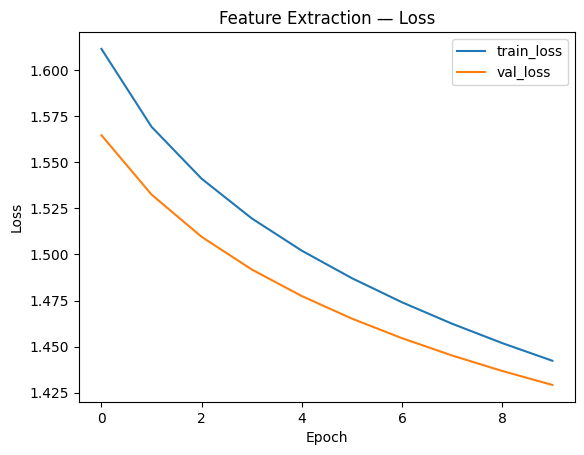

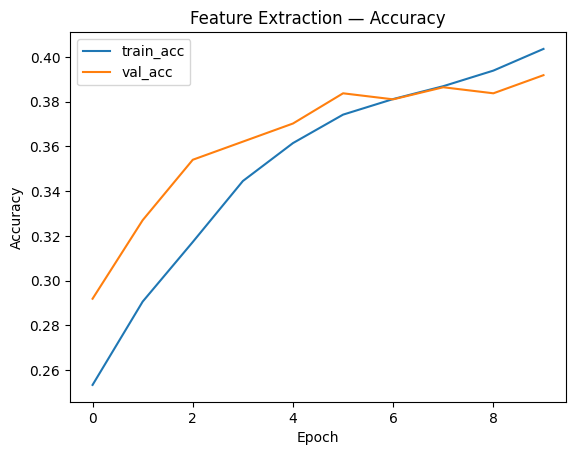

In [ ]:

# Build MobileNetV2 base (no top) + our small head (same simple Sequential feel)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze

# Full model
transfer_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

history_feature = transfer_model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=10,
    verbose=2
)

plot_history(history_feature, "Feature Extraction")


> **Note:** We just ran for **10 epochs**, but if we increase the number of epochs, the results may improve.

## Phase 2: Fine‑Tuning (unfreeze top layers, small LR)

Epoch 1/10
207/207 - 342s - 2s/step - accuracy: 0.3158 - loss: 3.3451 - val_accuracy: 0.2703 - val_loss: 1.7854
Epoch 2/10
207/207 - 322s - 2s/step - accuracy: 0.4648 - loss: 1.3461 - val_accuracy: 0.2432 - val_loss: 2.0142
Epoch 3/10
207/207 - 280s - 1s/step - accuracy: 0.5527 - loss: 1.1531 - val_accuracy: 0.2486 - val_loss: 2.3650
Epoch 4/10
207/207 - 321s - 2s/step - accuracy: 0.6188 - loss: 1.0198 - val_accuracy: 0.2676 - val_loss: 2.4991
Epoch 5/10
207/207 - 323s - 2s/step - accuracy: 0.6752 - loss: 0.9004 - val_accuracy: 0.2486 - val_loss: 2.9677
Epoch 6/10
207/207 - 322s - 2s/step - accuracy: 0.7394 - loss: 0.7967 - val_accuracy: 0.2351 - val_loss: 3.4821
Epoch 7/10
207/207 - 280s - 1s/step - accuracy: 0.7918 - loss: 0.6977 - val_accuracy: 0.2351 - val_loss: 4.3252
Epoch 8/10
207/207 - 311s - 2s/step - accuracy: 0.8342 - loss: 0.6099 - val_accuracy: 0.2351 - val_loss: 5.0601
Epoch 9/10
207/207 - 322s - 2s/step - accuracy: 0.8715 - loss: 0.5311 - val_accuracy: 0.2351 - val_loss:

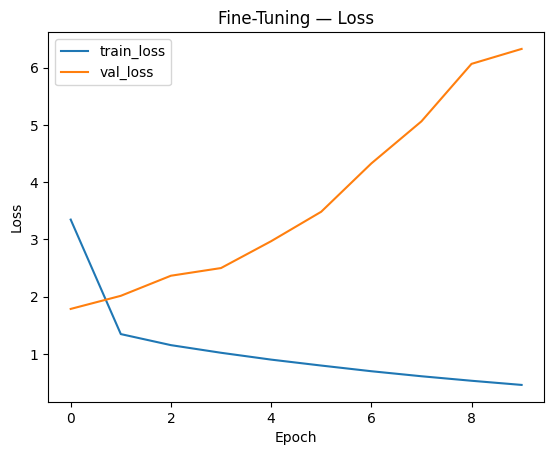

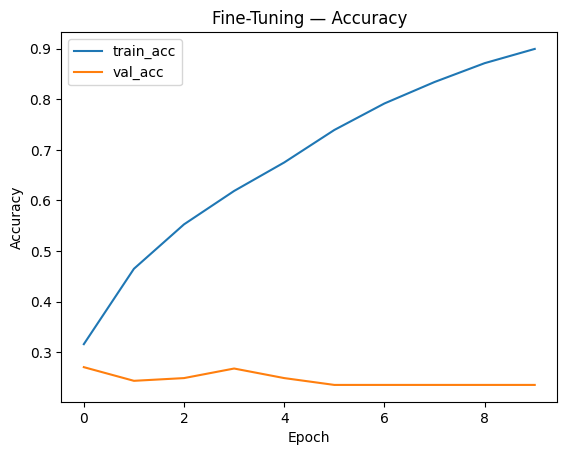

In [ ]:

# Unfreeze the top part of the base model
base_model.trainable = True

# Freeze most layers, keep only higher blocks trainable (tune the cutoff if needed)
fine_tune_at = 100
for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= fine_tune_at)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # very small LR
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

history_finetune = transfer_model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=10,
    verbose=2
)

plot_history(history_finetune, "Fine-Tuning")


> **Note:** We just ran for **10 epochs**, but if we increase the number of epochs, the results may improve.


## What to remember
- Start with **frozen base** ➜ then **small‑LR fine‑tuning**.  
- This mirrors P3’s clarity while giving a **big accuracy boost** on small datasets.  

# Learning rate rescheduling (for Fine‑Tuning)

- The **learning rate (LR)** controls how much we update model weights each step.  
- **If LR is too high:** the model may oscillate and never converge.  
- **If LR is too low:** the model learns very slowly.

**Problem:**  
In Transfer Learning we often start with a larger LR to quickly adapt the new classifier head,  
but later we need to **slow down** to fine‑tune the pre‑trained layers **carefully**.

**Solution:**  
**Reschedule (decay)** the learning rate during training.

---

## Fine‑tuning + LR Rescheduling (Exponential Decay)

We will:
1) Do **Feature Extraction** first (freeze the base; train the small head).  
2) **Unfreeze the top layers** of the base to fine‑tune.  
3) Use **ExponentialDecay** so LR gets smaller as training progresses (safer fine‑tuning).


Epoch 1/10
207/207 - 322s - 2s/step - accuracy: 0.7918 - loss: 0.5760 - val_accuracy: 0.5703 - val_loss: 1.1507
Epoch 2/10
207/207 - 317s - 2s/step - accuracy: 0.9927 - loss: 0.0392 - val_accuracy: 0.7054 - val_loss: 0.7898
Epoch 3/10
207/207 - 323s - 2s/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 0.8108 - val_loss: 0.5559
Epoch 4/10
207/207 - 379s - 2s/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.8405 - val_loss: 0.4481
Epoch 5/10
207/207 - 322s - 2s/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.8649 - val_loss: 0.3991
Epoch 6/10
207/207 - 322s - 2s/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8838 - val_loss: 0.3826
Epoch 7/10
207/207 - 271s - 1s/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8811 - val_loss: 0.3825
Epoch 8/10
207/207 - 276s - 1s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8784 - val_loss: 0.3871
Epoch 9/10
207/207 - 319s - 2s/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8757 - val_loss:

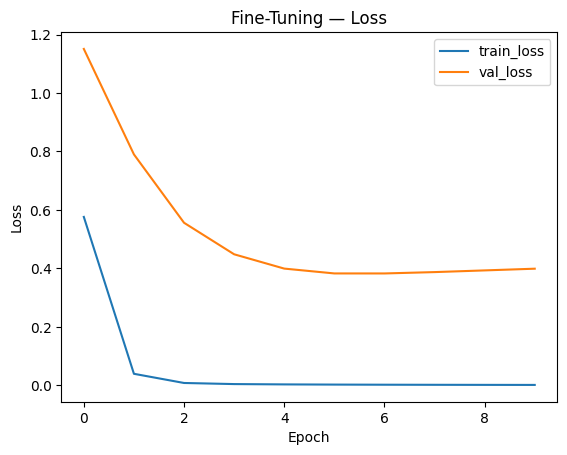

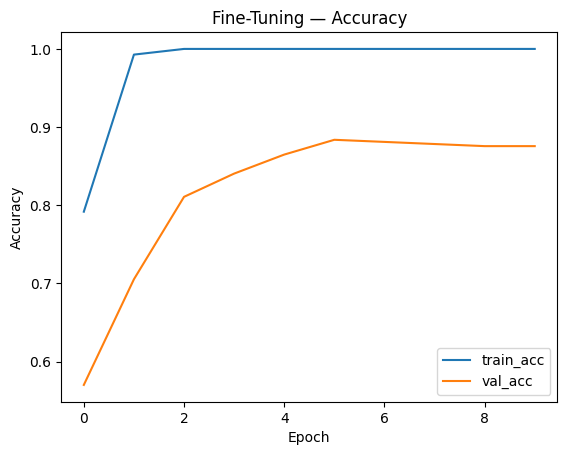

In [ ]:
from tensorflow import keras
model = keras.Sequential([
            base_model,
            keras.layers.GlobalAveragePooling2D(),
            keras.layers.BatchNormalization(),       # Add BatchNorm
            keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
        ])

initial_learning_rate = 0.0001

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=initial_learning_rate,
            decay_steps=100,
            decay_rate=0.96,
            staircase=True
        )

# Compile the model with the learning rate schedule
model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
            metrics=["accuracy"]
        )
history_finetune = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=10,
    verbose=2
)

plot_history(history_finetune, "Fine-Tuning")

> **Note:** We just ran for **10 epochs**, but if we increase the number of epochs, the results may improve.


# Differential Learning Rate (DLR): Train different parts with different LRs

**Why?** During fine‑tuning, we often want:
- **Very small LR** for the **pre‑trained base** (to avoid destroying good features).
- **Larger LR** for the **new head** (to learn task‑specific mappings quickly).


Epoch 1/10
207/207 - 691s - 3s/step - accuracy: 0.7609 - loss: 0.8170 - val_accuracy: 0.3811 - val_loss: 7.1509
Epoch 2/10
207/207 - 681s - 3s/step - accuracy: 0.8391 - loss: 0.4572 - val_accuracy: 0.4865 - val_loss: 6.4606
Epoch 3/10
207/207 - 682s - 3s/step - accuracy: 0.8273 - loss: 0.4725 - val_accuracy: 0.2838 - val_loss: 7.2147
Epoch 4/10
207/207 - 682s - 3s/step - accuracy: 0.8945 - loss: 0.3140 - val_accuracy: 0.3162 - val_loss: 12.3310
Epoch 5/10
207/207 - 683s - 3s/step - accuracy: 0.9067 - loss: 0.2591 - val_accuracy: 0.3865 - val_loss: 9.8520
Epoch 6/10
207/207 - 714s - 3s/step - accuracy: 0.9258 - loss: 0.2123 - val_accuracy: 0.4946 - val_loss: 7.5110
Epoch 7/10
207/207 - 683s - 3s/step - accuracy: 0.9364 - loss: 0.1807 - val_accuracy: 0.3378 - val_loss: 8.4418
Epoch 8/10
207/207 - 740s - 4s/step - accuracy: 0.9264 - loss: 0.2321 - val_accuracy: 0.2514 - val_loss: 14.1005
Epoch 9/10
207/207 - 683s - 3s/step - accuracy: 0.9424 - loss: 0.1805 - val_accuracy: 0.5405 - val_los

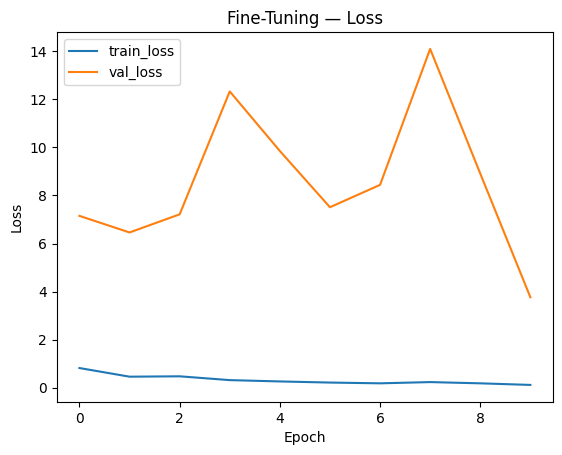

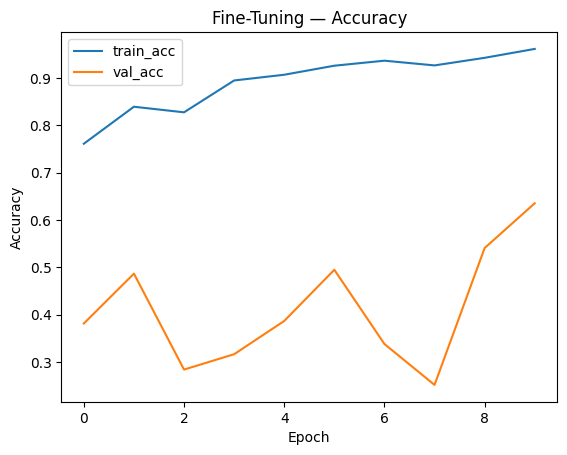

In [ ]:
model = keras.Sequential([
            base_model,
            keras.layers.GlobalAveragePooling2D(),
            keras.layers.BatchNormalization(),       # Add BatchNorm
            keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
        ])

base_learning_rate = 1e-5
head_learning_rate = 1e-4


optimizer = tf.keras.optimizers.Adam()

for layer in model.layers[0].layers:  # Layers inside base_model
            layer.trainable = True
            layer._learning_rate = base_learning_rate

for layer in model.layers[1:]:
            layer._learning_rate = head_learning_rate

# Compile the model with the learning rate schedule
model.compile(optimizer=optimizer,loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=["accuracy"])
history_finetune = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=10,
    verbose=2
)

plot_history(history_finetune, "Fine-Tuning")

> **Note:** We just ran for **10 epochs**, but if we increase the number of epochs, the results may improve.


---

## Coming Next: Hyperparameter Tuning with **Weights & Biases (W&B)**
In the **next practical**, we will:
- Track experiments (learning rate, batch size, augmentation, optimizer, etc.).
- Compare runs with interactive dashboards.
- Use **sweeps** to **automatically** try many settings and find good hyperparameters.

> You don’t need an account to read this notebook, but creating a free W&B account will make the next practical smoother.


---
*This Practical was designed to give you hands-on experience and a clear understanding of Transfer Learning concepts, including Feature Extraction, Fine-Tuning, and Differential Learning Rates*